<a href="https://colab.research.google.com/github/PinderMaksim/6.1.1/blob/main/Laba8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras import regularizers

In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

columns = ['age', 'workclass', 'fnlwgt', 'education', 'education-num',
           'marital-status', 'occupation', 'relationship', 'race', 'sex',
           'capital-gain', 'capital-loss', 'hours-per-week',
           'native-country', 'income']

data = pd.read_csv(url, names=columns, sep=',\s', engine='python')

data = data.replace('?', np.nan).dropna()

print(data.head())

<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3122/2039158967.py:8: SyntaxWarning: invalid escape sequence '\s'
  data = pd.read_csv(url, names=columns, sep=',\s', engine='python')


   age         workclass  fnlwgt  education  education-num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital-status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capital-gain  capital-loss  hours-per-week native-country income  
0          2174             0              40  United-States  <=50K  
1             0             0             

In [3]:
minority_size = len(data[data['income'] == '>50K'])

class1 = data[data['income'] == '>50K']
class0 = data[data['income'] == '<=50K'].sample(n=minority_size, random_state=42)

balanced_data = pd.concat([class0, class1])

print(balanced_data['income'].value_counts(normalize=True))

income
<=50K    0.5
>50K     0.5
Name: proportion, dtype: float64


In [4]:
balanced_data = balanced_data.drop('education', axis=1)

to_factor = ['workclass', 'marital-status', 'occupation',
             'relationship', 'race', 'sex', 'native-country']

balanced_data[to_factor] = balanced_data[to_factor].apply(
    lambda col: pd.factorize(col, sort=True)[0]
)

X = balanced_data.drop('income', axis=1)
Y = pd.get_dummies(balanced_data['income'])

In [5]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.15, random_state=42
)

mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

In [6]:
model = Sequential([

    Dense(16, input_dim=X_train.shape[1], activation="relu",
          kernel_regularizer=regularizers.l2(0.01)),
    BatchNormalization(),

    Dense(8, activation="relu"),
    Dropout(0.2),

    Dense(2, activation="softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(X_train, Y_train, epochs=50, validation_split=0.15, batch_size=16, callbacks=[early_stop], verbose=1)

Epoch 1/50
678/678 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6630 - loss: 0.7486 - val_accuracy: 0.7493 - val_loss: 0.5901
Epoch 2/50
678/678 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7609 - loss: 0.5752 - val_accuracy: 0.7838 - val_loss: 0.4961
Epoch 3/50
678/678 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7788 - loss: 0.5133 - val_accuracy: 0.7896 - val_loss: 0.4552
Epoch 4/50
678/678 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7837 - loss: 0.4857 - val_accuracy: 0.7916 - val_loss: 0.4404
Epoch 5/50
678/678 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7937 - loss: 0.4665 - val_accuracy: 0.7984 - val_loss: 0.4279
Epoch 6/50
678/678 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7939 - loss: 0.4618 - val_accuracy: 0.8010 - val_loss: 0.4196
Epoch 7/50
678/678 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7959 - loss: 0.4513 - val_accuracy: 0.8084 - val_loss: 0.4147
Epoch 8/50
678/678 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7961 - loss: 0.4486 - val_accuracy: 0.

Фінальна точність на тесті: 81.27%


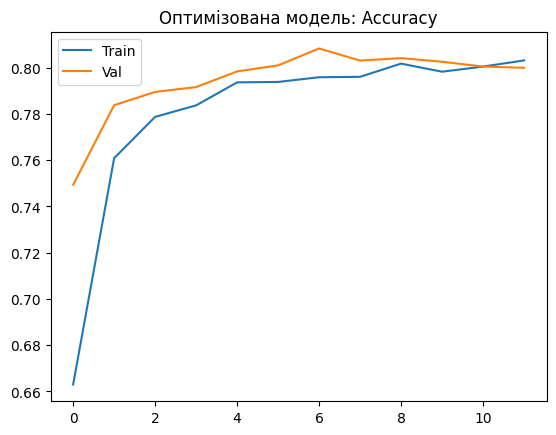

In [8]:
loss, accuracy = model.evaluate(X_test, Y_test, verbose=0)
print(f"Фінальна точність на тесті: {accuracy*100:.2f}%")

plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Оптимізована модель: Accuracy')
plt.legend()
plt.show()